# Belief Propogation

This notebook develops the **sum-product belief propagation algorithm** for discrete, tree-structured factor graphs.

The notebook covers:

1. The intuition behind message passing
2. Variable-to-factor messages
3. Factor-to-variable messages
4. Marginal beliefs'
5. A Python implementation
6. Verification against direct enumeration

Belief propagation replaces one centralized inference calculation with local computations between neighboring nodes.

## 1. From Variable Elimination to local message passing

Suppose a joint distribution factorizes as

$$
P(X_1,\ldots,X_n)
=
\frac{1}{Z}
\prod_{f\in\mathcal{F}}
f(\mathbf{X}_f),
$$

where:

- $\mathcal{F}$ is the set of factors,
- $\mathbf{X}_f$ is the scope of factor $f$,
- $Z$ is a normalization constant.

Variable elimination computes a marginal by repeatedly multiplying factors and summing out hidden variables.

Belief propagation reorganizes the same operations as **local messages** on a factor graph.

A message can be understood as:

> A summary of all information available at the sender, excluding information received from the recipient.

Because a factor graph is bipartite, there are only two message types:

$$
\text{variable} \rightarrow \text{factor}
$$

and

$$
\text{factor} \rightarrow \text{variable}.
$$


## 2. Variable-to-factor messages

Let variable $X$ send a message to neighboring factor $f$.

The variable collects messages from every other neighboring factor and multiplies them:

$$
m_{X\rightarrow f}(x)
=
\prod_{h\in N(X)\setminus\{f\}}
m_{h\rightarrow X}(x).
$$

Here, $N(X)$ denotes the factors connected to $X$.

The destination factor $f$ is excluded because $X$ should not immediately return information that originally came from $f$.

### Leaf-variable case

If $X$ has no neighboring factor other than $f$, the product is empty.

By convention, an empty product equals one:

$$
m_{X\rightarrow f}(x)=1.
$$

Therefore, a leaf variable sends an all-ones message over its domain.

## 3. Factor-to-variable messages

Let factor $f$ send a message to variable $X$.

The factor:

1. starts with its own factor table,
2. multiplies incoming messages from all other variables,
3. sums out every variable except $X$.

The message is

$$
m_{f\rightarrow X}(x)
=
\sum_{\mathbf{x}_{f}\setminus\{x\}}
f(\mathbf{x}_f)
\prod_{Y\in N(f)\setminus\{X\}}
m_{Y\rightarrow f}(y).
$$


This is a local variable-elimination computation.

For a unary factor $f(X)$, there are no other variables to eliminate, so

$$
m_{f\rightarrow X}(x)=f(x).
$$


## 4. Belief at a variable

After variable $X$ receives messages from all neighboring factors, its unnormalized belief is

$$
\widetilde{b}_X(x)
=
\prod_{f\in N(X)}
m_{f\rightarrow X}(x).
$$

The normalized belief is

$$
b_X(x)
=
\frac{
\widetilde{b}_X(x)
}{
\sum_{x'}\widetilde{b}_X(x')
}.
$$

Equivalently,

$$
b_X(x)
\propto
\prod_{f\in N(X)}
m_{f\rightarrow X}(x).
$$

For a tree-structured factor graph, the normalized belief equals the exact marginal:

$$
b_X(x)=P(X=x).
$$

## 5. Imports

This notebook assumes that the previously implemented `Factor` and `FactorGraph` classes are available.

Update the import paths below to match your project structure.

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Hashable

import numpy as np

In [2]:
%%capture
%run "../01_Representation/05_DiscreteFactor.ipynb"
%run "../02_Inference/04_Factor_Graph.ipynb"

Exception: File `'../01_Representation/05_DiscreteFactor.ipynb'` not found.

## 6. Implementation strategy

Messages are stored as NumPy arrays rather than full `Factor` objects.

For a variable $X$ with domain

$$
\operatorname{dom}(X)=\{x_1,\ldots,x_k\},
$$

a message is represented as

$$
\begin{bmatrix}
m(x_1) & \cdots & m(x_k)
\end{bmatrix}.
$$

Two caches are maintained:

- `variable_to_factor_messages[(X, f)]`
- `factor_to_variable_messages[(f, X)]`

The recursive implementation is especially natural on trees because removing an edge separates the graph into independent subtrees.

In [26]:
@dataclass
class BeliefPropagation:
    """
    Sum-product belief propagation for a discrete tree-structured
    FactorGraph.

    Parameters
    ----------
    factor_graph:
        A FactorGraph containing discrete Factor objects.

    normalize_messages:
        If True, normalize every nonzero message. Message normalization
        does not change the final beliefs because belief propagation
        messages are defined only up to a positive scale.
    """

    factor_graph: FactorGraph
    normalize_messages: bool = True

    variable_to_factor_messages: dict[
        tuple[str, str],
        np.ndarray,
    ] = field(
        init=False,
        repr=False,
    )

    factor_to_variable_messages: dict[
        tuple[str, str],
        np.ndarray,
    ] = field(
        init=False,
        repr=False,
    )

    def __post_init__(self) -> None:
        if not self.factor_graph.validate_bipartite():
            raise ValueError(
                "Belief propagation requires a valid bipartite "
                "factor graph."
            )

        if not self.factor_graph.is_tree():
            raise ValueError(
                "This implementation supports exact belief "
                "propagation only on connected trees."
            )

        self.variable_to_factor_messages = {}
        self.factor_to_variable_messages = {}

    def clear_messages(self) -> None:
        """Remove all cached messages."""

        self.variable_to_factor_messages.clear()
        self.factor_to_variable_messages.clear()

    def _domain_size(self, variable: str) -> int:
        return len(self.factor_graph.get_domain(variable))

    def _normalize(self, values: np.ndarray) -> np.ndarray:
        """
        Normalize a nonnegative message if requested.

        A zero message is returned unchanged because it cannot be
        normalized.
        """

        values = np.asarray(values, dtype=float)

        if not self.normalize_messages:
            return values

        total = values.sum()

        if total > 0.0:
            return values / total

        return values

    def variable_to_factor(
        self,
        variable: str,
        factor_name: str,
    ) -> np.ndarray:
        """
        Compute m_{variable -> factor}(variable).

        The result is a one-dimensional array ordered according to the
        stored domain of `variable`.
        """

        if factor_name not in self.factor_graph.incident_factors(
            variable
        ):
            raise ValueError(
                f"Variable {variable!r} is not connected to factor "
                f"{factor_name!r}."
            )

        key = (variable, factor_name)

        if key in self.variable_to_factor_messages:
            return self.variable_to_factor_messages[key].copy()

        message = np.ones(
            self._domain_size(variable),
            dtype=float,
        )

        for neighboring_factor in self.factor_graph.incident_factors(
            variable
        ):
            if neighboring_factor == factor_name:
                continue

            incoming = self.factor_to_variable(
                neighboring_factor,
                variable,
            )

            message *= incoming

        message = self._normalize(message)
        self.variable_to_factor_messages[key] = message

        return message.copy()

    def factor_to_variable(
        self,
        factor_name: str,
        variable: str,
    ) -> np.ndarray:
        """
        Compute m_{factor -> variable}(variable).

        Incoming variable messages are broadcast to the corresponding
        axes of the factor table. All axes except the destination
        variable's axis are then summed out.
        """

        if variable not in self.factor_graph.incident_variables(
            factor_name
        ):
            raise ValueError(
                f"Factor {factor_name!r} is not connected to "
                f"variable {variable!r}."
            )

        key = (factor_name, variable)

        if key in self.factor_to_variable_messages:
            return self.factor_to_variable_messages[key].copy()

        factor = self.factor_graph.get_factor(factor_name)
        weighted_values = np.asarray(
            factor.values,
            dtype=float,
        ).copy()

        for neighboring_variable in factor.variables:
            if neighboring_variable == variable:
                continue

            incoming = self.variable_to_factor(
                neighboring_variable,
                factor_name,
            )

            axis = factor.variables.index(neighboring_variable)

            reshape = [1] * weighted_values.ndim
            reshape[axis] = len(incoming)

            weighted_values *= incoming.reshape(reshape)

        destination_axis = factor.variables.index(variable)

        axes_to_sum = tuple(
            axis
            for axis in range(weighted_values.ndim)
            if axis != destination_axis
        )

        if axes_to_sum:
            message = weighted_values.sum(axis=axes_to_sum)
        else:
            message = weighted_values

        message = np.asarray(message, dtype=float).reshape(-1)
        message = self._normalize(message)

        self.factor_to_variable_messages[key] = message

        return message.copy()

    def belief(self, variable: str) -> np.ndarray:
        """
        Compute the normalized marginal belief of a variable.
        """

        if variable not in self.factor_graph.variables:
            raise KeyError(
                f"Unknown variable {variable!r}."
            )

        belief_values = np.ones(
            self._domain_size(variable),
            dtype=float,
        )

        for factor_name in self.factor_graph.incident_factors(
            variable
        ):
            belief_values *= self.factor_to_variable(
                factor_name,
                variable,
            )

        total = belief_values.sum()

        if total <= 0.0:
            raise ValueError(
                f"The belief for variable {variable!r} cannot be "
                "normalized because its total mass is zero."
            )

        return belief_values / total

    def run(self) -> dict[str, np.ndarray]:
        """
        Compute beliefs for every variable in the factor graph.
        """

        return {
            variable: self.belief(variable)
            for variable in self.factor_graph.variables
        }

    def message_table(self) -> dict[str, dict[tuple[str, str], np.ndarray]]:
        """
        Return copies of all currently cached messages.
        """

        return {
            "variable_to_factor": {
                key: value.copy()
                for key, value
                in self.variable_to_factor_messages.items()
            },
            "factor_to_variable": {
                key: value.copy()
                for key, value
                in self.factor_to_variable_messages.items()
            },
        }


## 7. Test graph

We use the chain

$$
P(A,B,C)
=
\phi_A(A)\,
\phi_{AB}(A,B)\,
\phi_{BC}(B,C).
$$

Its factor graph is

```text
phi_A -- A -- phi_AB -- B -- phi_BC -- C
```

The variables are binary:

$$
A,B,C\in\{0,1\}.
$$

We choose

$$
\phi_A(A)
=
\begin{bmatrix}
0.6 & 0.4
\end{bmatrix},
$$

$$
\phi_{AB}(A,B)
=
\begin{bmatrix}
0.7 & 0.3 \\
0.2 & 0.8
\end{bmatrix},
$$

and

$$
\phi_{BC}(B,C)
=
\begin{bmatrix}
0.9 & 0.1 \\
0.4 & 0.6
\end{bmatrix}.
$$

The rows and columns follow the variable order stored in each factor.

In [27]:
binary_domain = [0, 1]

factor_a = Factor(
    variables=["A"],
    domains={
        "A": binary_domain,
    },
    values=np.array([
        0.6,
        0.4,
    ]),
    name="phi_A",
)

factor_ab = Factor(
    variables=["A", "B"],
    domains={
        "A": binary_domain,
        "B": binary_domain,
    },
    values=np.array([
        [0.7, 0.3],
        [0.2, 0.8],
    ]),
    name="phi_AB",
)

factor_bc = Factor(
    variables=["B", "C"],
    domains={
        "B": binary_domain,
        "C": binary_domain,
    },
    values=np.array([
        [0.9, 0.1],
        [0.4, 0.6],
    ]),
    name="phi_BC",
)

factor_graph = FactorGraph(
    factors={
        "phi_A": factor_a,
        "phi_AB": factor_ab,
        "phi_BC": factor_bc,
    }
)

factor_graph


FactorGraph(variables=['A', 'B', 'C'], factors=['phi_A', 'phi_AB', 'phi_BC'], edges=5)

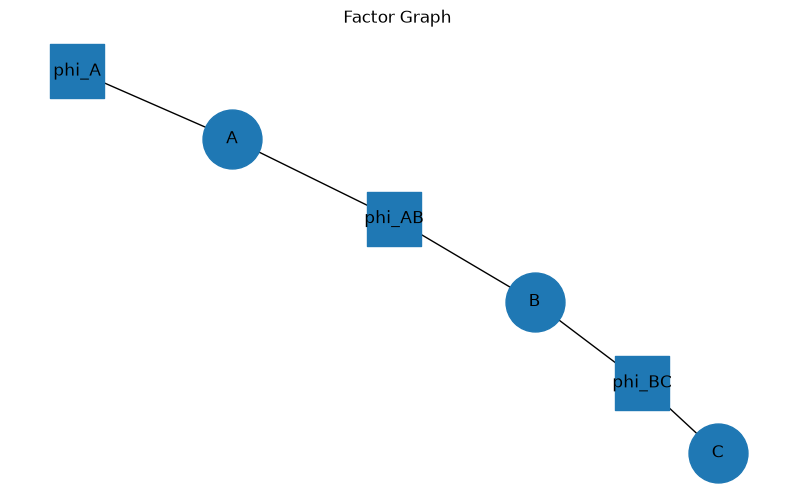

In [28]:
factor_graph.plot()

## 8. Running belief propagation

For this tree, messages propagate inward from the leaves and are reused when computing beliefs.

For example, the information from $C$ reaches $B$ through

$$
C
\rightarrow
\phi_{BC}
\rightarrow
B.
$$

The belief of $B$ combines messages from both neighboring factors:

$$
b_B(b)
\propto
m_{\phi_{AB}\rightarrow B}(b)
m_{\phi_{BC}\rightarrow B}(b).
$$


In [29]:
bp = BeliefPropagation(factor_graph)

beliefs = bp.run()

for variable, values in beliefs.items():
    domain = factor_graph.get_domain(variable)

    print(f"Belief for {variable}:")
    for state, probability in zip(domain, values):
        print(f"  P({variable}={state}) = {probability:.6f}")
    print()


Belief for A:
  P(A=0) = 0.600000
  P(A=1) = 0.400000

Belief for B:
  P(B=0) = 0.500000
  P(B=1) = 0.500000

Belief for C:
  P(C=0) = 0.650000
  P(C=1) = 0.350000



## 9. Inspecting individual messages

The variable-to-factor message

$$
m_{B\rightarrow\phi_{AB}}(b)
$$

contains information reaching $B$ from the opposite side of the graph, excluding $\phi_{AB}$.

Therefore, it includes information from

$$
\phi_{BC}
$$

but not information from

$$
\phi_{AB}.
$$


In [30]:
message_b_to_ab = bp.variable_to_factor(
    "B",
    "phi_AB",
)

message_bc_to_b = bp.factor_to_variable(
    "phi_BC",
    "B",
)

print("m_{B -> phi_AB} =", message_b_to_ab)
print("m_{phi_BC -> B} =", message_bc_to_b)


m_{B -> phi_AB} = [0.5 0.5]
m_{phi_BC -> B} = [0.5 0.5]


## 10. Verification by direct enumeration

To verify the implementation independently, we construct the complete unnormalized joint table:

$$
\widetilde{P}(A,B,C)
=
\phi_A(A)
\phi_{AB}(A,B)
\phi_{BC}(B,C).
$$

After normalization,

$$
P(A,B,C)
=
\frac{
\widetilde{P}(A,B,C)
}{
\sum_{a,b,c}\widetilde{P}(a,b,c)
}.
$$

The exact marginal of $B$ is then

$$
P(B)
=
\sum_{A,C}P(A,B,C).
$$


In [31]:
joint_unnormalized = (
    factor_a.values[:, None, None]
    * factor_ab.values[:, :, None]
    * factor_bc.values[None, :, :]
)

joint = joint_unnormalized / joint_unnormalized.sum()

exact_a = joint.sum(axis=(1, 2))
exact_b = joint.sum(axis=(0, 2))
exact_c = joint.sum(axis=(0, 1))

exact_beliefs = {
    "A": exact_a,
    "B": exact_b,
    "C": exact_c,
}

for variable in factor_graph.variables:
    print(
        variable,
        np.allclose(
            beliefs[variable],
            exact_beliefs[variable],
        ),
    )


A True
B True
C True


In [32]:
for variable in factor_graph.variables:
    print(f"{variable}:")
    print("  Belief propagation:", beliefs[variable])
    print("  Direct enumeration:", exact_beliefs[variable])
    print()


A:
  Belief propagation: [0.6 0.4]
  Direct enumeration: [0.6 0.4]

B:
  Belief propagation: [0.5 0.5]
  Direct enumeration: [0.5 0.5]

C:
  Belief propagation: [0.65 0.35]
  Direct enumeration: [0.65 0.35]



## 11. Why the recursive implementation works on a tree

Consider computing

$$
m_{X\rightarrow f}(x).
$$

Removing the edge between $X$ and $f$ divides a tree into two disconnected components.

The message from $X$ to $f$ summarizes all factors and variables in the component on the $X$ side of that removed edge.

Similarly,

$$
m_{f\rightarrow X}(x)
$$

summarizes the component on the factor side.

Because a tree contains no cycles, the recursive calls cannot return to the same edge from another route. Every message therefore has a well-defined dependency structure.

Caching ensures that each directed message is calculated only once.

## 12. Relationship with variable elimination

The factor-to-variable equation is

$$
m_{f\rightarrow X}(x)
=
\sum_{\mathbf{x}_{f}\setminus\{x\}}
f(\mathbf{x}_f)
\prod_{Y\in N(f)\setminus\{X\}}
m_{Y\rightarrow f}(y).
$$

This performs the same two operations used in variable elimination:

1. multiplication,
2. marginalization.

The difference is organizational:

- **Variable elimination** chooses a global elimination order.
- **Belief propagation** caches and reuses local elimination results as messages.

On a tree, this reuse allows all single-variable marginals to be computed efficiently.

## 13. Computational interpretation

Suppose a factor graph has variable nodes $\mathcal{V}$, factor nodes $\mathcal{F}$, and edges $\mathcal{E}$.

Every undirected edge carries two directed messages:

$$
X\rightarrow f
$$

and

$$
f\rightarrow X.
$$

Thus, a complete tree pass requires at most

$$
2|\mathcal{E}|
$$

directed messages.

The cost of a factor-to-variable message depends mainly on the size of the factor table. Large factor scopes remain expensive because their table sizes grow exponentially with the number of variables in the scope.

## 14. Evidence

Evidence can be introduced by restricting the relevant factors before constructing the factor graph.

For evidence

$$
E=e,
$$

replace every factor containing $E$ by its restricted version:

$$
f(\mathbf{X}_f)
\longrightarrow
f(\mathbf{X}_f)\big|_{E=e}.
$$

After restriction, run belief propagation on the resulting factors.

An alternative implementation can introduce an indicator factor

$$
\delta_e(E)
=
\begin{cases}
1, & E=e,\\
0, & E\neq e.
\end{cases}
$$

Both approaches encode the same evidence.

## 15. Limitations

This implementation deliberately requires a connected tree.

For a tree:

$$
b_X(x)=P(X=x)
$$

after all required messages have been computed.

For a graph containing cycles, repeatedly applying the same equations gives **loopy belief propagation**.

In loopy belief propagation:

- messages may converge,
- messages may oscillate,
- convergence is not always guaranteed,
- converged beliefs may only approximate the true marginals.

Exact inference on general cyclic graphical models usually requires methods such as the junction-tree algorithm or variable elimination.

## 16. Summary

The sum-product algorithm consists of three equations.

### Variable to factor

$$
m_{X\rightarrow f}(x)
=
\prod_{h\in N(X)\setminus\{f\}}
m_{h\rightarrow X}(x).
$$

### Factor to variable

$$
m_{f\rightarrow X}(x)
=
\sum_{\mathbf{x}_{f}\setminus\{x\}}
f(\mathbf{x}_f)
\prod_{Y\in N(f)\setminus\{X\}}
m_{Y\rightarrow f}(y).
$$

### Variable belief

$$
b_X(x)
=
\frac{
\prod_{f\in N(X)}
m_{f\rightarrow X}(x)
}{
\sum_{x'}
\prod_{f\in N(X)}
m_{f\rightarrow X}(x')
}.
$$

The main insight is that each message summarizes one side of an edge. On a tree, combining the incoming summaries gives the exact marginal belief.